# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Shahzaib Mahar

**Roll Number:** _(023-24-0282)_

**GitHub Repository:** https://github.com/smaharx/ml-forge




> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")



: 

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company wants to understand why customers are leaving and identify customers who are likely to leave in the future. This can help the company take action before custions churn. target is churn and it tells who leaves and who stays.

**Answer 2:**
1. tenure: longer tenure (less likely to churn)
2. Contract: it tells about customer commitment
3. monthlycharges: different payment accounts for churn behavior
4. intenetservice: it tells about customer usage and satisfaction
5. techSupport: customers with/without technical support may have different churn behavior

Useless:
1. customerid: it is unique for each customer and does not provide any information about churn
2. gender: it is not related to churn behavior

**Answer 3:** 
1. Do customers with short tenure churn more or less?
2. Does the type of contract affect churn behavior?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [21]:
# Task 4 — dataset shape, column names, data types

""" There are 7,043 customers and 21 columns in the dataset. Out of these, 20 columns are input features and Churn is the target variable.

Numerical features:
SeniorCitizen
tenure
MonthlyCharges
TotalCharges

Categorical features: all others 
customerId is and identifier
"""

' There are 7,043 customers and 21 columns in the dataset. Out of these, 20 columns are input features and Churn is the target variable.\n\nNumerical features:\nSeniorCitizen\ntenure\nMonthlyCharges\nTotalCharges\n\nCategorical features: all others \ncustomerId is and identifier\n'

In [22]:
# Task 5 — identify identifier columns / wrong data types
df.head(2)

# only customerID is identifier

# customerID is an identifier rather than a useful predictive feature because it uniquely identifies customers and has no meaningful customer behavior information. TotalCharges appears to have the wrong data type because it represents a numeric billing amount but is stored as object/text.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [23]:
# Task 6 — unique values in 3 categorical columns

for col in ["gender", "Contract", "InternetService"]:
    print(f"\n{col}:")
    print(df[col].unique())
    
# gender contains the expected categories Male and Female. Contract contains Month-to-month, One year, and Two year, while InternetService contains DSL, Fiber optic, and No. No unexpected or inconsistently formatted categories were found in these three columns.



gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Contract:
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

### The dataset contains 7,043 customers and 21 columns. customerID is an identifier and should not be used as a predictive feature. TotalCharges represents a numerical billing value but is stored as text/object, so its data type needs to be corrected. The checked categorical columns contain consistent expected categories with no obvious formatting problems.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [24]:
# Task 7 — missing values: count and percentage per column

missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

print(missing_report)

                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [25]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


In [26]:
# Task 9 — investigate a suspicious / invalid value
print("TotalCharges values that cannot be converted to numbers:")

total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df.loc[
    total_charges_numeric.isna() & df["TotalCharges"].notna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
])

print("\nNumber of non-numeric TotalCharges values:",
      (total_charges_numeric.isna() & df["TotalCharges"].notna()).sum())

TotalCharges values that cannot be converted to numbers:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             

Number of non-numeric TotalCharges values: 11


**Answer 7 (which missing-value problems need action, and why):**
_(Missing values were checked using both counts and percentages. Missing values in important predictive columns require action because they can prevent the model from using those records correctly. Columns with no missing values require no action.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean the entire record is repeated, while duplicate customer IDs mean the same customer identifier appears more than once, even if the other information is different. Both checks are therefore necessary.)_

**Answer 9 (suspicious value found and how):**
# TotalCharges contains values that are not valid numeric values even though the column represents a monetary amount. I found them by converting TotalCharges with pd.to_numeric(errors="coerce") and checking which original non-null values became NaN.


---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges stored as text/object | Convert to numeric | `pd.to_numeric(..., errors='coerce')` | TotalCharges represents a numerical billing amount and must have a numerical data type. |
| Non-numeric/blank TotalCharges values | Treat them as missing values | `pd.to_numeric(..., errors='coerce')` | Invalid text values cannot be used in numerical analysis and are therefore converted to NaN. |
| Missing numerical values | Fill with the median | `fillna(median)` | The median is less affected by extreme values than the mean and avoids unnecessarily deleting customer records. |
| Duplicate rows | Remove exact duplicate rows | `drop_duplicates()` | Exact duplicate records provide no additional information and can bias analysis. |
| Duplicate customer IDs | Remove duplicate customer records | `drop_duplicates(subset="customerID")` | Each customer should have one record, so repeated customer IDs should not remain. |
| `customerID` is an identifier | Remove the column from the cleaned dataset | `drop(columns="customerID")` | It identifies customers but does not represent a useful predictive characteristic. |

In [27]:
# Task 11 — apply your cleaning decisions here
cleaned_df = df.copy()

# Remove extra spaces from text columns
for col in cleaned_df.select_dtypes(include="object").columns:
    cleaned_df[col] = cleaned_df[col].str.strip()

# Convert TotalCharges to numeric
cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

# Fill missing numerical values with median
numeric_columns = cleaned_df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())

# Fill missing categorical values with mode
categorical_columns = cleaned_df.select_dtypes(include="object").columns

for col in categorical_columns:
    if cleaned_df[col].isnull().sum() > 0:
        cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].mode()[0])

# Remove exact duplicate rows
cleaned_df = cleaned_df.drop_duplicates()

# Remove duplicate customer IDs
cleaned_df = cleaned_df.drop_duplicates(subset="customerID")

# Remove identifier column
cleaned_df = cleaned_df.drop(columns="customerID")

cleaned_df.head()

C:\Users\UserX\AppData\Local\Temp\ipykernel_16712\1364752776.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in cleaned_df.select_dtypes(include="object").columns:
C:\Users\UserX\AppData\Local\Temp\ipykernel_16712\1364752776.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/us

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values:")
print(cleaned_df.isnull().sum())

print("\nDuplicate rows:", cleaned_df.duplicated().sum())

print("\nData types:")
print(cleaned_df.dtypes)

print("\nShape after cleaning:", cleaned_df.shape)

# All identified data-quality issues were resolved. The cleaned dataframe contains no missing values, no duplicate rows, and TotalCharges has been converted to a numerical data type.

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 22

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      fl

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

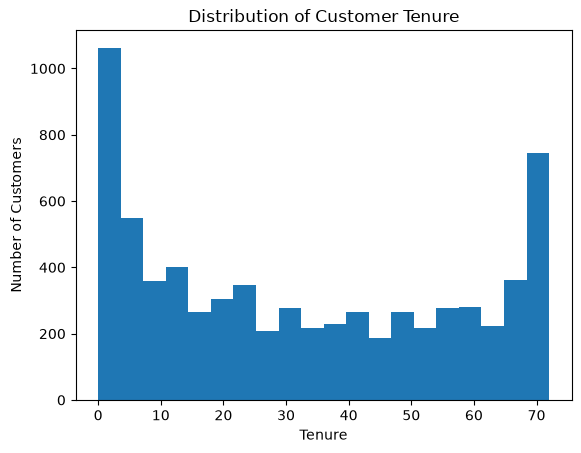

In [29]:
# Task 12 — numerical feature 1: distribution plot

cleaned_df["tenure"].plot(kind="hist", bins=20)

plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")

plt.show()


**Observation:** _(what did you learn from this chart?)_
# Most customers have lower to medium tenure, while fewer customers have very high tenure. The distribution is spread across the range of customer tenure.

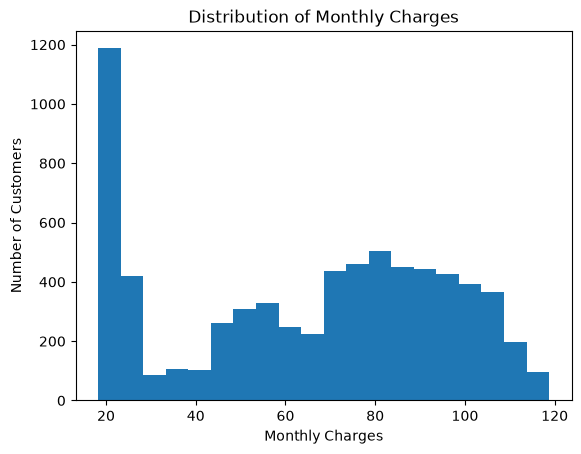

In [30]:
# Task 12 — numerical feature 2: distribution plot

cleaned_df["MonthlyCharges"].plot(kind="hist", bins=20)

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")

plt.show()

**Observation:** _(what did you learn from this chart?)_
# Monthly charges are spread across a wide range of values. Most customers have charges in the middle range, with fewer customers having very low or very high charges.

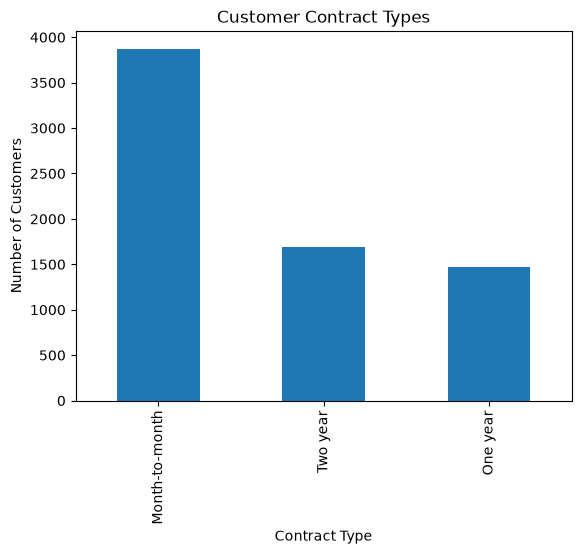

In [31]:
# Task 12 — categorical feature 1: distribution plot

cleaned_df["Contract"].value_counts().plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Contract Types")

plt.show()

**Observation:** _(what did you learn from this chart?)_
# Month-to-month contracts are the most common. One-year and two-year contracts have fewer customers.

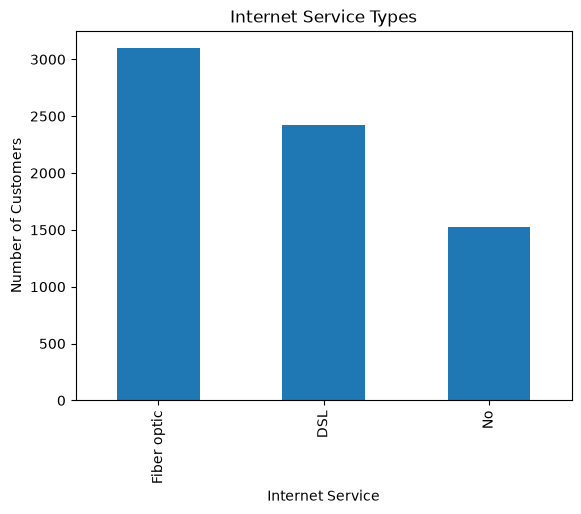

In [32]:
# Task 12 — categorical feature 2: distribution plot

cleaned_df["InternetService"].value_counts().plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Internet Service Types")

plt.show()

**Observation:** _(what did you learn from this chart?)_
# The customers are divided among DSL, Fiber optic, and customers without internet service. Fiber optic and DSL are common service types, while customers without internet service form another large group.


**Answer 13 (outliers / skew and possible explanation):**
# Some numerical features show skewness. MonthlyCharges has some customers with very high charges, while tenure is spread across different customer lengths. These patterns can be explained by customers having different service plans, prices, and lengths of time with the company.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [33]:
# Task 14 — churn counts and percentages

churn_counts = cleaned_df["Churn"].value_counts()
churn_percentages = cleaned_df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
# The target variable is imbalanced because the number of customers who did not churn is much higher than the number of customers who churned.

**Answer 15 (why imbalance might matter later):**
# Class imbalance matters because a model may perform well by mostly predicting the larger class. This can make the model's overall accuracy look good even when it does a poor job of identifying customers who actually churn.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [34]:
# Task 16 — categorical feature 1 vs Churn

print(pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"],
    normalize="index"
) * 100)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


**Observation:** Customers with month-to-month contracts have a higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The percentage of Churn = Yes is higher for Month-to-month contracts in the table above.

**Possible Explanation:** Month-to-month customers have less commitment and can leave the company more easily.

In [35]:
# Task 16 — categorical feature 2 vs Churn

print(pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
) * 100)


Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


**Observation:** Customers with Fiber optic service have a higher churn rate than customers with DSL or no internet service.

**Evidence:** The percentage of Churn = Yes is higher for Fiber optic customers in the table above.

**Possible Explanation:** Fiber optic customers may have higher costs or may be more likely to switch to another provider.

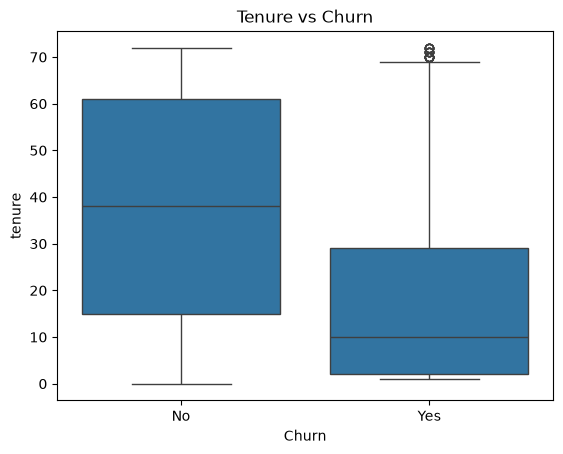

In [36]:
# Task 17 — numerical feature 1 vs Churn

sns.boxplot(x="Churn", y="tenure", data=cleaned_df)

plt.title("Tenure vs Churn")
plt.show()

**Observation:** Customers who churn tend to have lower tenure than customers who do not churn.

**Evidence:** The boxplot shows that the Churn = Yes group generally has lower tenure values.

**Possible Explanation:** Newer customers may be less attached to the company and may leave more easily.

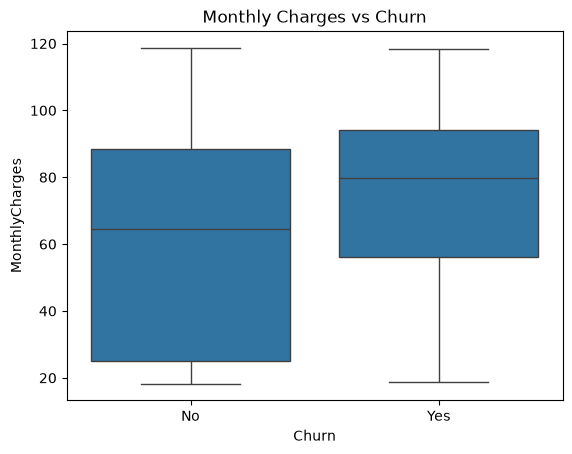

In [37]:
# Task 17 — numerical feature 2 vs Churn

sns.boxplot(x="Churn", y="MonthlyCharges", data=cleaned_df)

plt.title("Monthly Charges vs Churn")
plt.show()

**Observation:** Customers who churn generally have higher monthly charges than customers who do not churn.

**Evidence:** The boxplot shows a higher typical MonthlyCharges value for the Churn = Yes group.

**Possible Explanation:** Customers paying more each month may be more likely to look for cheaper alternatives.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000


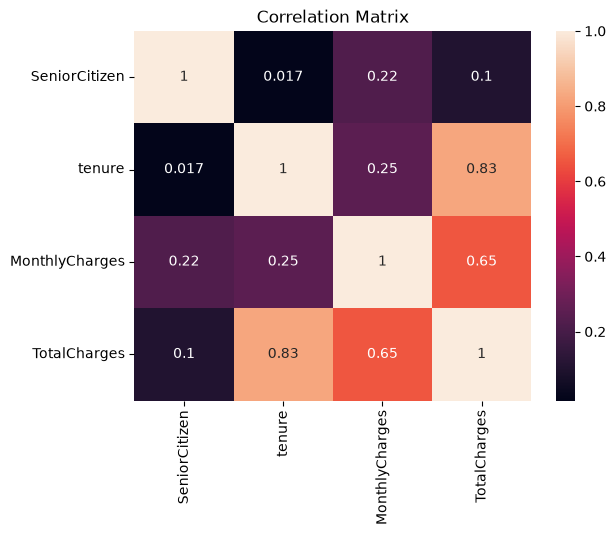

In [38]:
# Task 18 — correlation matrix and heatmap

correlation = cleaned_df.corr(numeric_only=True)

print(correlation)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")
plt.show()

**Answer 18 (most correlated pairs):**
# The strongest correlation is between tenure and TotalCharges. This makes sense because customers who stay longer usually pay more total charges. MonthlyCharges has a much weaker relationship with tenure.

**Answer 19 (correlation vs. causation; potential problems):**
# Correlation does not mean that one variable causes another. Highly correlated features can provide similar information and may cause redundancy in a future model, making the model harder to interpret.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.


**Answer 20 (suspect columns and reasoning):**
# customerID is a suspect because it is only an identifier and does not describe customer behavior. Churn should not be used as an input feature because it is the target we are trying to predict. The other columns describe customer information that could normally be available before predicting churn.

**Answer 21 (what would go wrong):**
# If a leakage column is used, the model may get information that would not actually be available when making a prediction. This can make the model look very accurate during testing but perform poorly on real customers.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | It only identifies the customer and is not useful for prediction. |
| gender | Categorical | Feature | Keep | It contains customer information that can be used as a feature. |
| SeniorCitizen | Numerical | Feature | Keep | It gives information about whether the customer is a senior citizen. |
| Partner | Categorical | Feature | Keep | It gives information about the customer's situation. |
| Dependents | Categorical | Feature | Keep | It gives information about whether the customer has dependents. |
| tenure | Numerical | Feature | Keep | It shows how long the customer has stayed with the company. |
| PhoneService | Categorical | Feature | Keep | It gives information about the customer's phone service. |
| MultipleLines | Categorical | Feature | Keep | It gives information about the customer's phone lines. |
| InternetService | Categorical | Feature | Keep | It gives information about the customer's internet service. |
| OnlineSecurity | Categorical | Feature | Keep | It gives information about the customer's online security service. |
| OnlineBackup | Categorical | Feature | Keep | It gives information about the customer's backup service. |
| DeviceProtection | Categorical | Feature | Keep | It gives information about device protection. |
| TechSupport | Categorical | Feature | Keep | It gives information about technical support. |
| StreamingTV | Categorical | Feature | Keep | It gives information about the customer's streaming TV service. |
| StreamingMovies | Categorical | Feature | Keep | It gives information about the customer's streaming movie service. |
| Contract | Categorical | Feature | Keep | Contract type is related to customer churn. |
| PaperlessBilling | Categorical | Feature | Keep | It gives information about the customer's billing method. |
| PaymentMethod | Categorical | Feature | Keep | It gives information about how the customer pays. |
| MonthlyCharges | Numerical | Feature | Keep | It shows the customer's monthly charge. |
| TotalCharges | Numerical | Feature | Keep | It shows the total amount charged to the customer after converting it to numeric. |
| Churn | Categorical | Target | Keep | This is the value we want the future model to predict. |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [39]:
# Task 23 — assemble clean_df

clean_df = df.copy()

# Remove extra spaces
for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = clean_df[col].str.strip()

# Convert TotalCharges to numbers
clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

# Fill missing numerical values with median
clean_df["TotalCharges"] = clean_df["TotalCharges"].fillna(
    clean_df["TotalCharges"].median()
)

clean_df["tenure"] = clean_df["tenure"].fillna(
    clean_df["tenure"].median()
)

clean_df["MonthlyCharges"] = clean_df["MonthlyCharges"].fillna(
    clean_df["MonthlyCharges"].median()
)

# Fill missing categorical values with mode
for col in clean_df.select_dtypes(include="object").columns:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].mode()[0]
    )

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Remove duplicate customer IDs
clean_df = clean_df.drop_duplicates(
    subset="customerID"
)

# Remove customer ID
clean_df = clean_df.drop(
    columns="customerID"
)

# Save the cleaned dataset
clean_df.to_csv(
    "clean_churn.csv",
    index=False
)

print(clean_df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

C:\Users\UserX\AppData\Local\Temp\ipykernel_16712\2963690855.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_df.select_dtypes(include="object").columns:
C:\Users\UserX\AppData\Local\Temp\ipykernel_16712\2963690855.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user

In [40]:
# Task 24 — final proof

print("Data information:")
clean_df.info()

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: TotalCharges was stored as text.
- Evidence: It had object data type instead of numeric.
- Interpretation: It needed to be changed to numeric before analysis.

**Finding 2**
- Observation: Some customers have churned and some did not.
- Evidence: The Churn column has two classes, Yes and No.
- Interpretation: The classes are not balanced, so accuracy alone can be misleading.

**Finding 3**
- Observation: Month-to-month customers churn more.
- Evidence: The churn percentage was higher for month-to-month contracts.
- Interpretation: Customers with less contract commitment may leave more easily.

**Finding 4**
- Observation: Customers with lower tenure tend to churn more.
- Evidence: The tenure boxplot showed lower values for customers who churned.
- Interpretation: New customers may be less attached to the company.

**Finding 5**
- Observation: tenure and TotalCharges have a strong correlation.
- Evidence: The correlation matrix showed a strong positive correlation.
- Interpretation: Customers who stay longer usually have higher total charges.

---

**Task 26 — Final Reflection Questions**
1. What was the most important data-quality issue you found?

TotalCharges was stored as text even though it is a numerical value. This could cause problems in analysis and ML.

2. What was the most interesting pattern you discovered?

Month-to-month customers had more churn compared to longer contracts.

3. Which feature seems most useful for predicting churn?

Contract seems very useful because the churn rate is different between contract types.

4. Which feature should probably not be used, and why?

customerID should not be used because it only identifies the customer and does not give useful information for prediction.

5. What preprocessing will be required before ML modeling?

Categorical columns will need to be encoded and the data may need scaling depending on the model.

6. What would you do next if you had another 3 hours?

I would check more feature relationships and then start preparing the data for the ML model.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

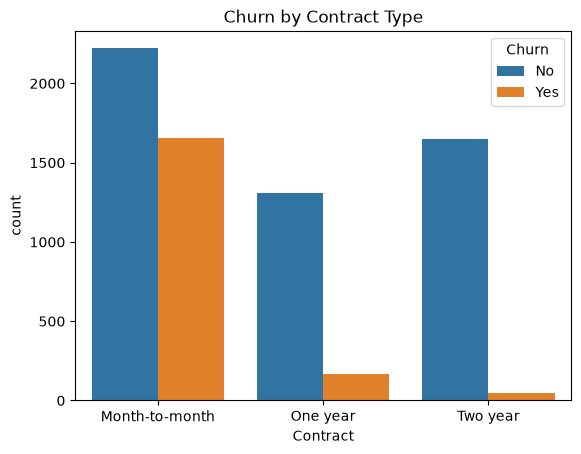

Fiber optic customers:
Churn
No     1799
Yes    1297
Name: count, dtype: int64
Churn rate by Contract and Internet Service:
Contract        InternetService
Month-to-month  DSL                32.215863
                Fiber optic        54.605263
                No                 18.893130
One year        DSL                 9.298246
                Fiber optic        19.294991
                No                  2.472527
Two year        DSL                 1.910828
                Fiber optic         7.226107
                No                  0.783699
Name: Yes, dtype: float64
   TotalCharges  tenure  AvgMonthlyCharge
0         29.85       1         14.925000
1       1889.50      34         53.985714
2        108.15       2         36.050000
3       1840.75      45         40.016304
4        151.65       2         50.550000
gender
Male      3555
Female    3488
Name: count, dtype: int64
gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
      

In [41]:
# Bonus — optional exploration

# Bonus 1 — additional visualization

sns.countplot(x="Contract", hue="Churn", data=clean_df)

plt.title("Churn by Contract Type")
plt.show()


# Bonus 2 — surprising customer subgroup

fiber_customers = clean_df[clean_df["InternetService"] == "Fiber optic"]

print("Fiber optic customers:")
print(fiber_customers["Churn"].value_counts())


# Bonus 3 — churn rate across 2 customer segments

churn_rate = pd.crosstab(
    [clean_df["Contract"], clean_df["InternetService"]],
    clean_df["Churn"],
    normalize="index"
) * 100

print("Churn rate by Contract and Internet Service:")
print(churn_rate["Yes"])


# Bonus 4 — feature engineering idea

clean_df["AvgMonthlyCharge"] = (
    clean_df["TotalCharges"] / (clean_df["tenure"] + 1)
)

print(clean_df[["TotalCharges", "tenure", "AvgMonthlyCharge"]].head())


# Bonus 5 — possible bias

print(clean_df["gender"].value_counts())
print(clean_df.groupby("gender")["Churn"].value_counts(normalize=True))

**Bonus 1:** The chart shows that churn is different between contract types. Month-to-month customers have more churn.

**Bonus 2:** Fiber optic customers are a interesting subgroup because they have higher churn compared to some other internet service groups.

**Bonus 3:** Churn rate changes when Contract and InternetService are looked at together. This gives more detail than looking at only one feature.

**Bonus 4:** AvgMonthlyCharge can be made from TotalCharges and tenure. It may give the model another useful feature about customer spending.

**Bonus 5:** Gender can be a possible source of bias if the dataset has unequal groups or the churn rates are different between groups.

---

## Submission Checklist

Before submitting, confirm you have:

* [ ✅ ] Completed all 26 tasks above, with written interpretation for every chart and decision
* [ ✅ ] A working `clean_df`, saved as `clean_churn.csv`
* [ ✅ ] A completed ML-readiness table (Part 10) covering every column
* [ ✅ ] Five Key Findings written (Part 12)
* [ ✅ ] Answered all six Final Reflection questions
* [ ✅ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
* [ ✅ ] Added your GitHub repository link at the top of this notebook
